In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
automobile = fetch_ucirepo(id=10)

# data (as pandas dataframes)
X = automobile.data.features
y = automobile.data.targets

# metadata
print(automobile.metadata)

# variable information
print(automobile.variables)


{'uci_id': 10, 'name': 'Automobile', 'repository_url': 'https://archive.ics.uci.edu/dataset/10/automobile', 'data_url': 'https://archive.ics.uci.edu/static/public/10/data.csv', 'abstract': "From 1985 Ward's Automotive Yearbook", 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 205, 'num_features': 25, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['symboling'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1985, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5B01C', 'creators': ['Jeffrey Schlimmer'], 'intro_paper': None, 'additional_info': {'summary': 'This data set consists of three types of entities: (a) the specification of an auto in terms of various characteristics, (b) its assigned insurance risk rating, (c) its normalized losses in use as compared to other cars.  The second rating corresponds to the degree to which th

In [6]:
print(X)

       price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0    13495.0           27        21    5000.0       111.0                9.0   
1    16500.0           27        21    5000.0       111.0                9.0   
2    16500.0           26        19    5000.0       154.0                9.0   
3    13950.0           30        24    5500.0       102.0               10.0   
4    17450.0           22        18    5500.0       115.0                8.0   
..       ...          ...       ...       ...         ...                ...   
200  16845.0           28        23    5400.0       114.0                9.5   
201  19045.0           25        19    5300.0       160.0                8.7   
202  21485.0           23        18    5500.0       134.0                8.8   
203  22470.0           27        26    4800.0       106.0               23.0   
204  22625.0           25        19    5400.0       114.0                9.5   

     stroke  bore fuel-system  engine-s

In [7]:
print(y)

     symboling
0            3
1            3
2            1
3            2
4            2
..         ...
200         -1
201         -1
202         -1
203         -1
204         -1

[205 rows x 1 columns]


In [8]:
print(X.dtypes)

price                float64
highway-mpg            int64
city-mpg               int64
peak-rpm             float64
horsepower           float64
compression-ratio    float64
stroke               float64
bore                 float64
fuel-system              str
engine-size            int64
num-of-cylinders       int64
engine-type              str
curb-weight            int64
height               float64
width                float64
length               float64
wheel-base           float64
engine-location          str
drive-wheels             str
body-style               str
num-of-doors         float64
aspiration               str
fuel-type                str
make                     str
normalized-losses    float64
dtype: object


In [9]:
print(y.dtypes)

symboling    int64
dtype: object


In [10]:
df = pd.concat([X, y], axis=1)

string = ["fuel-system", "engine-type", "engine-location", "drive-wheels", "body-style", "aspiration", "fuel-type", "make"]

for col in df.columns:
    if col in string:
        print(df[col].value_counts(normalize=True)) #conta as ocorrencias e divide essa contagem pelo total dando a frequencia relativa


fuel-system
mpfi    0.458537
2bbl    0.321951
idi     0.097561
1bbl    0.053659
spdi    0.043902
4bbl    0.014634
mfi     0.004878
spfi    0.004878
Name: proportion, dtype: float64
engine-type
ohc      0.721951
ohcf     0.073171
ohcv     0.063415
dohc     0.058537
l        0.058537
rotor    0.019512
dohcv    0.004878
Name: proportion, dtype: float64
engine-location
front    0.985366
rear     0.014634
Name: proportion, dtype: float64
drive-wheels
fwd    0.585366
rwd    0.370732
4wd    0.043902
Name: proportion, dtype: float64
body-style
sedan          0.468293
hatchback      0.341463
wagon          0.121951
hardtop        0.039024
convertible    0.029268
Name: proportion, dtype: float64
aspiration
std      0.819512
turbo    0.180488
Name: proportion, dtype: float64
fuel-type
gas       0.902439
diesel    0.097561
Name: proportion, dtype: float64
make
toyota           0.156098
nissan           0.087805
mazda            0.082927
honda            0.063415
mitsubishi       0.063415
subaru   

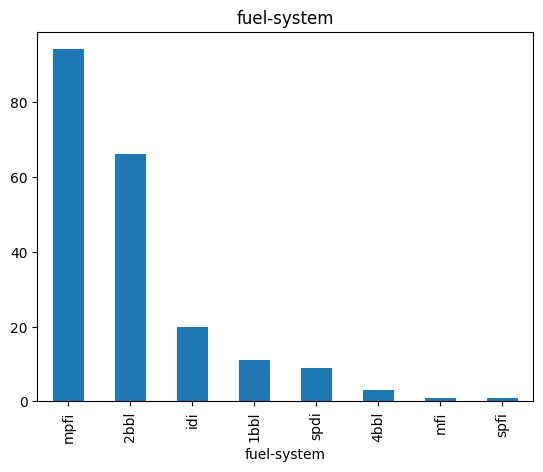

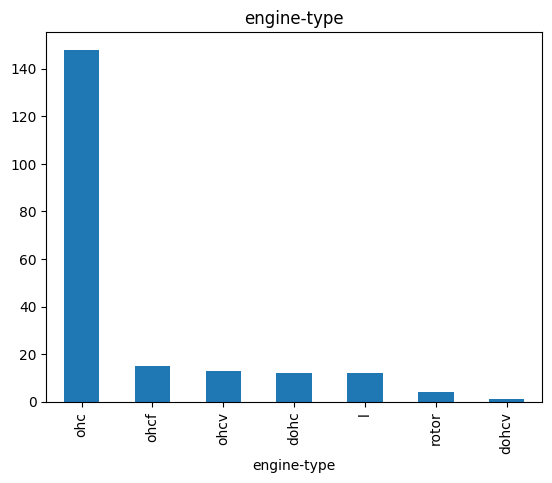

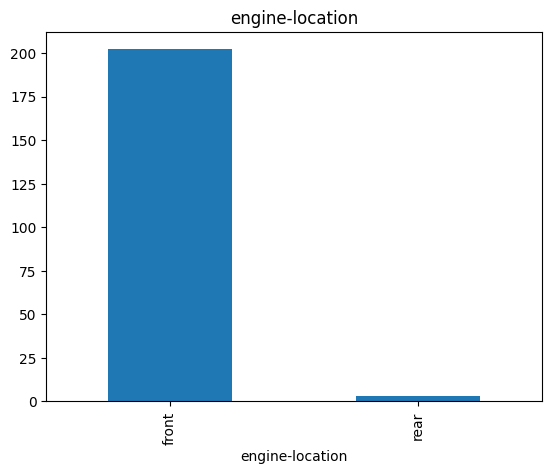

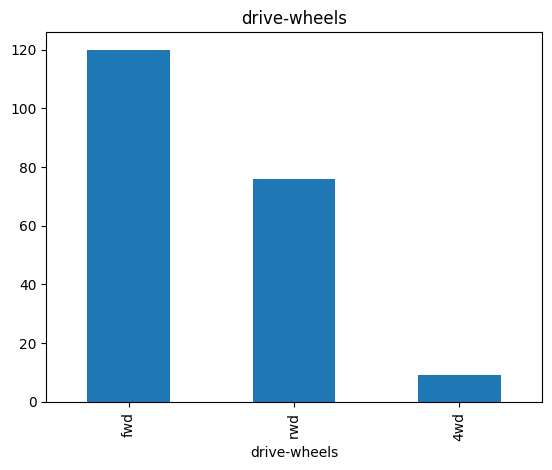

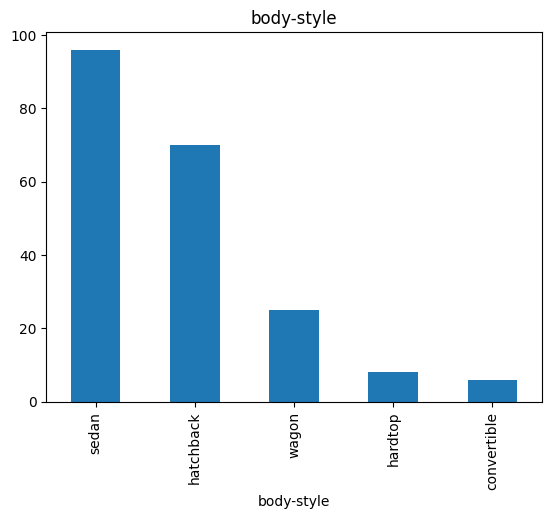

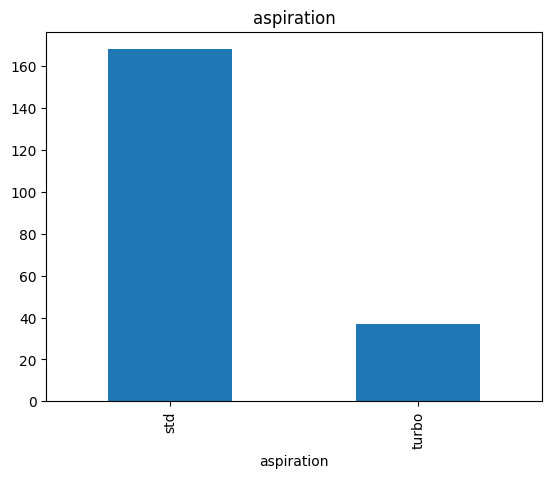

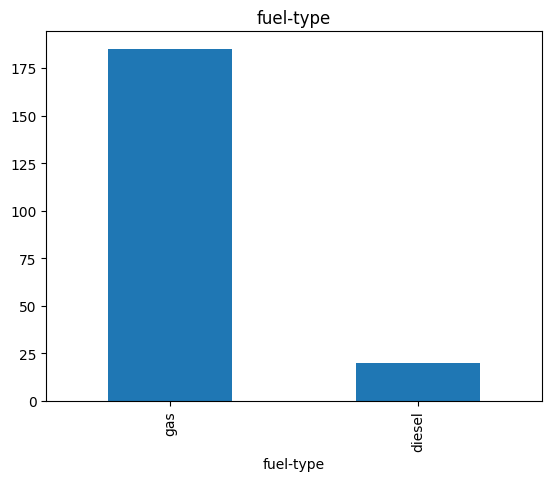

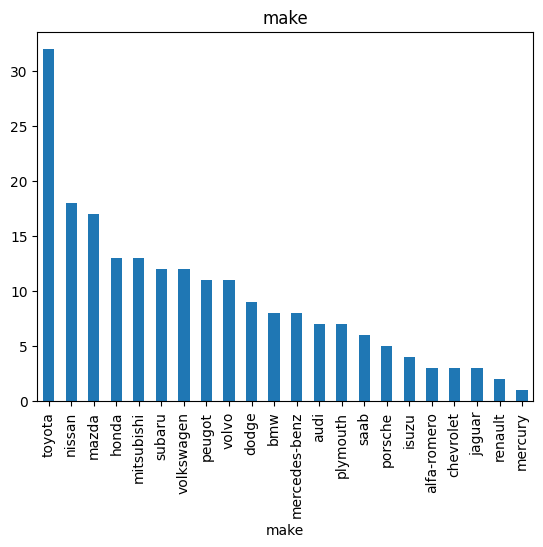

In [11]:
for col in df.columns:
    if col in string:
        df[col].value_counts().plot(kind='bar', title=col)
        plt.show()




In [12]:
type(df["make"].value_counts())

pandas.Series

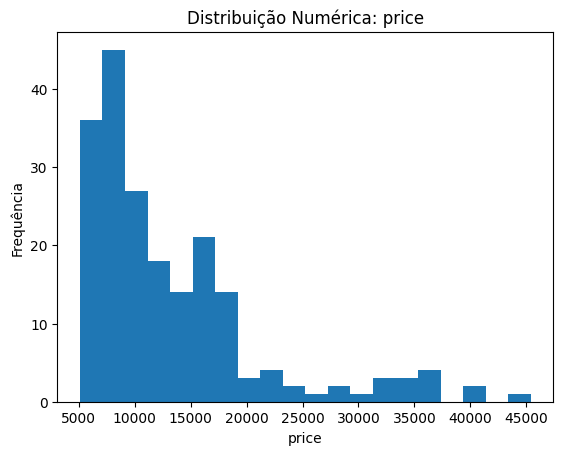

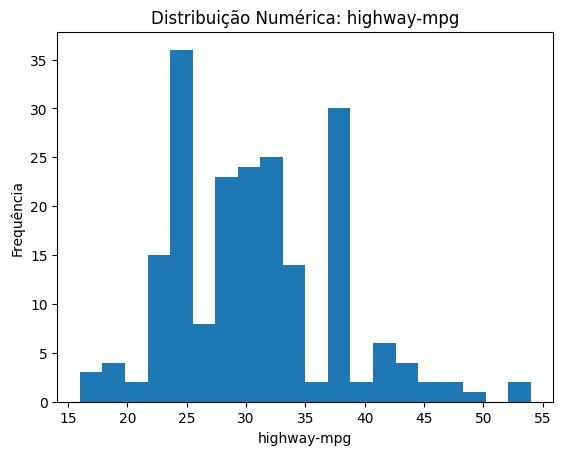

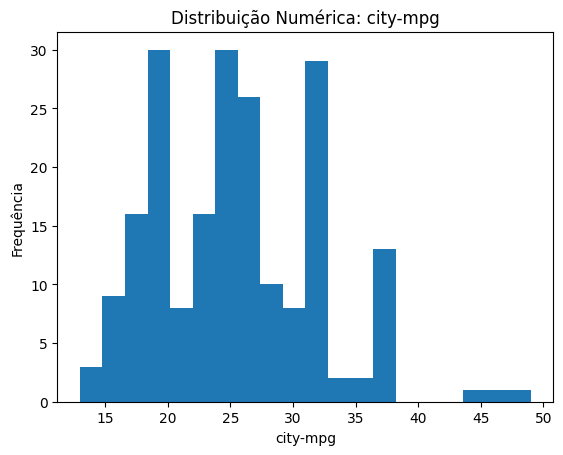

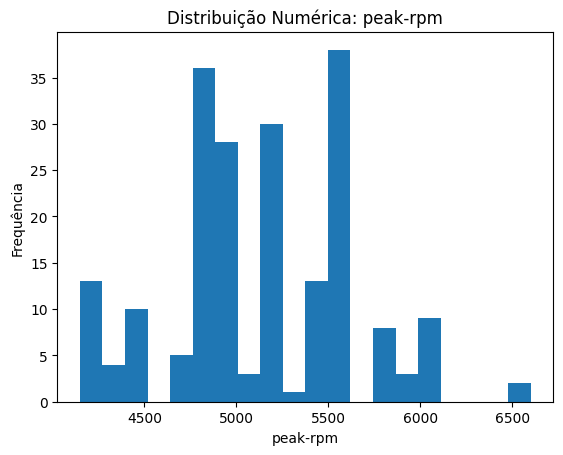

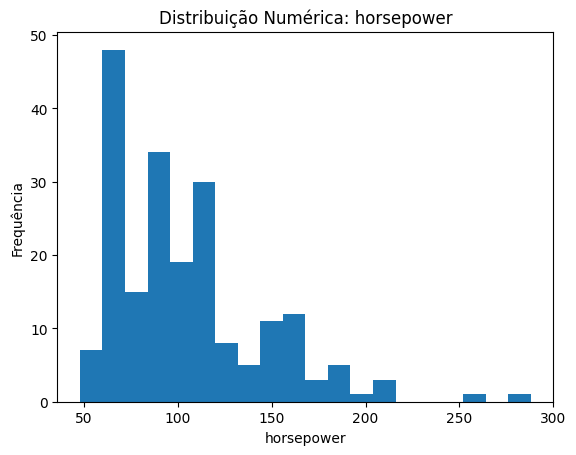

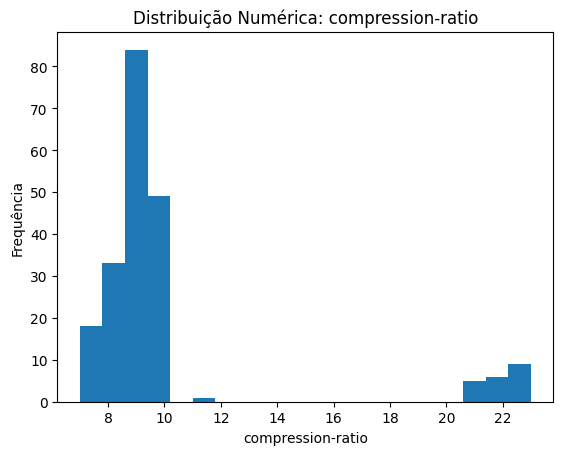

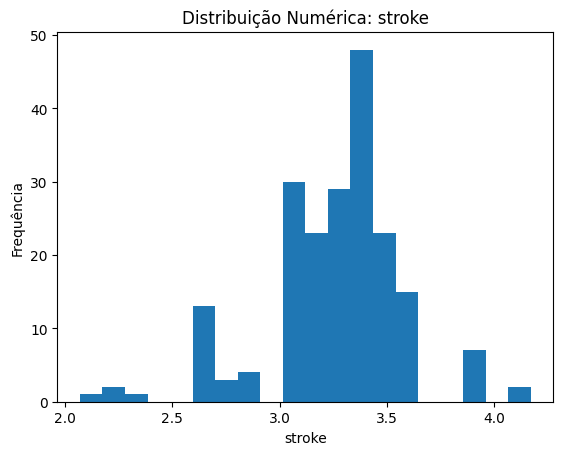

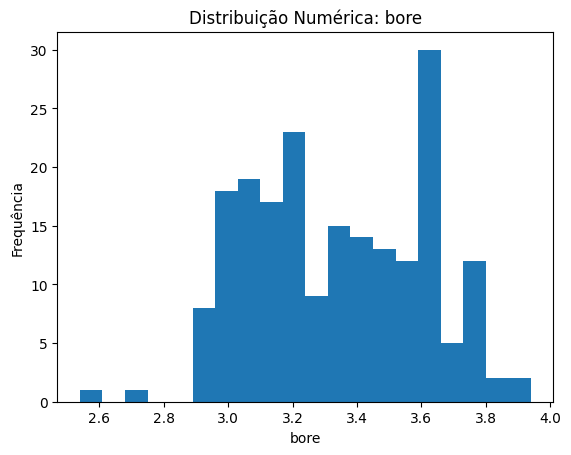

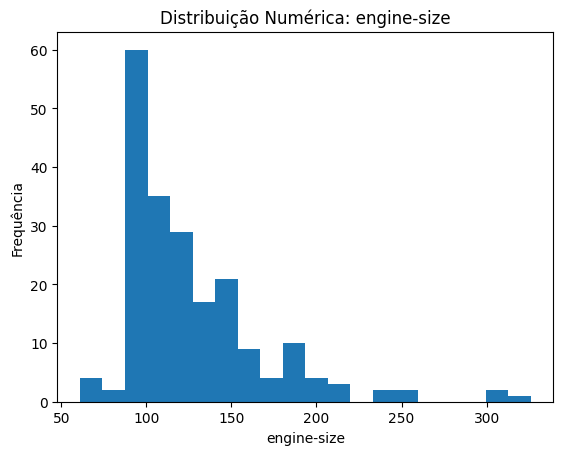

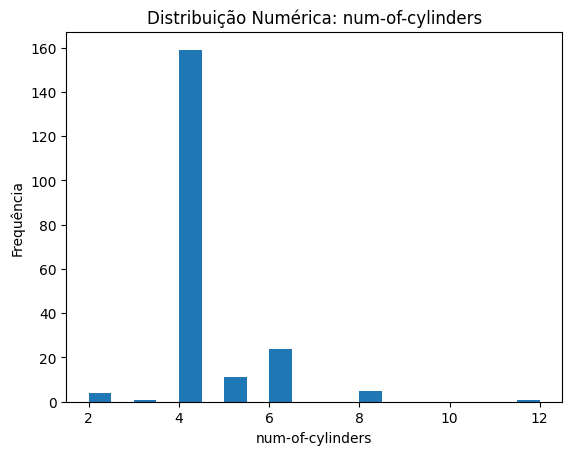

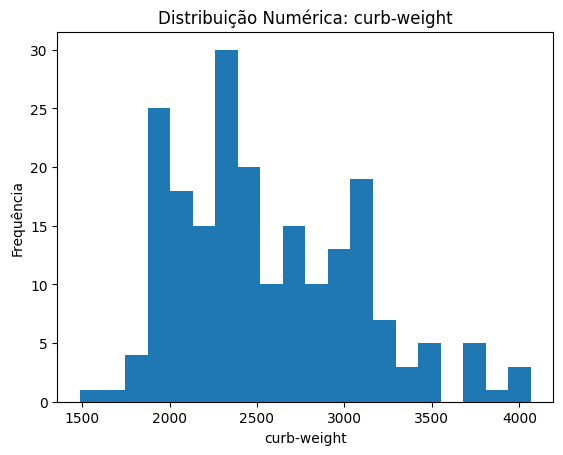

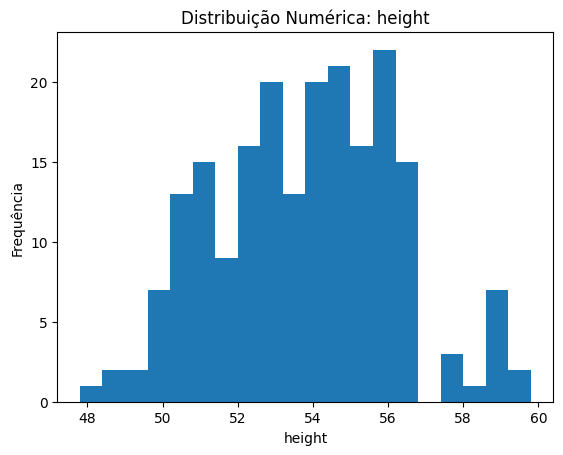

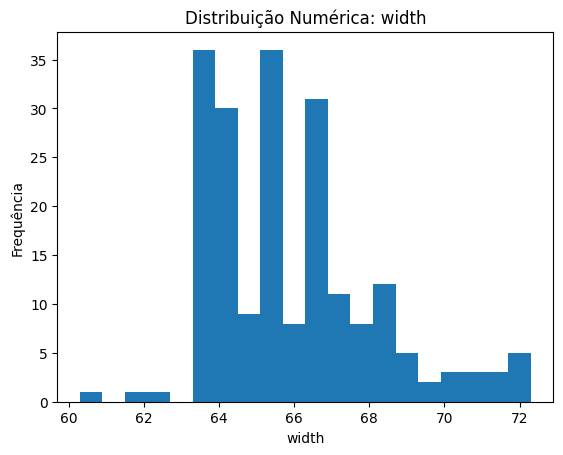

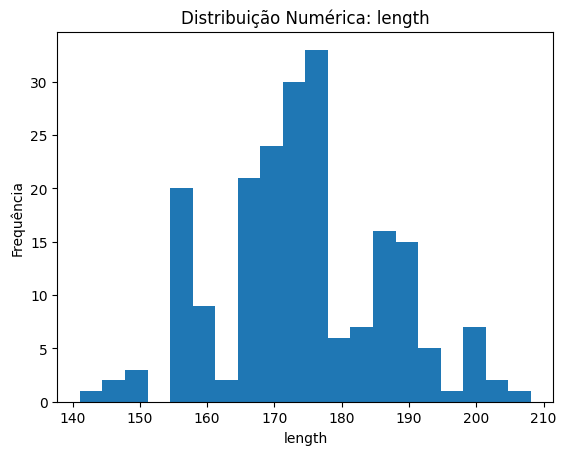

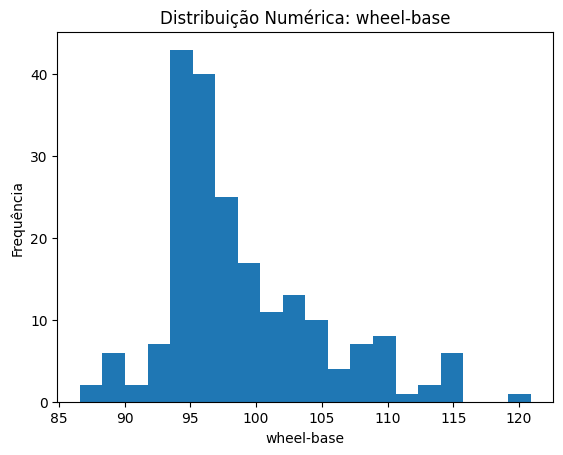

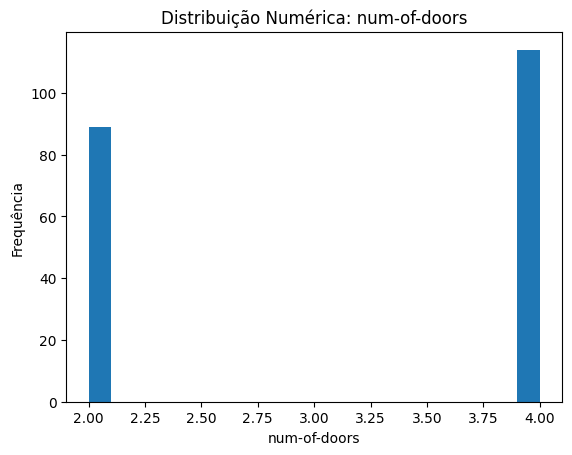

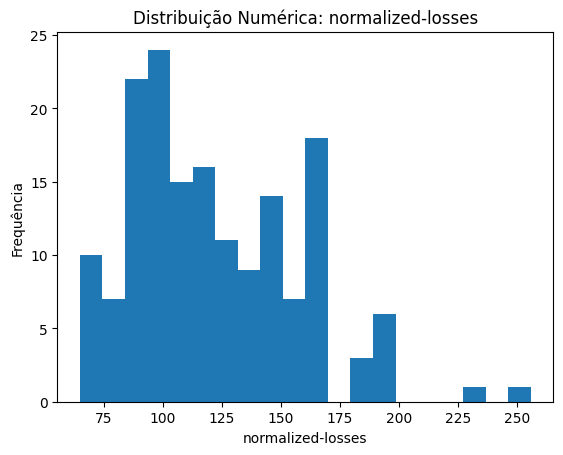

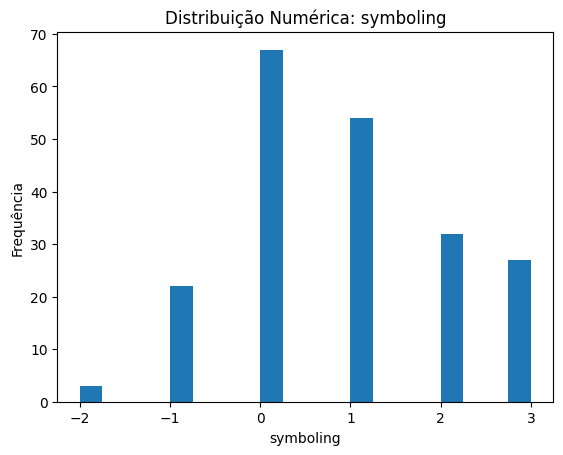

In [13]:
for col in df.columns:
    if col not in string:
        df[col].plot(kind='hist', bins=20, title=f"Distribuição Numérica: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.show()

In [14]:
for col in df.columns:
    if col not in string:
        print(f"\n--- Analisando Coluna: {col} ---")

        # Medidas de Tendência Central
        print(f"Média: {df[col].mean()}")
        print(f"Mediana: {df[col].median()}")

        # Medidas de Dispersão
        print(f"Desvio Padrão: {df[col].std()}")

        # Medidas de Simetria
        print(f"Simetria (Skewness): {df[col].skew()}")


--- Analisando Coluna: price ---
Média: 13207.129353233831
Mediana: 10295.0
Desvio Padrão: 7947.066341939274
Simetria (Skewness): 1.8096753390980749

--- Analisando Coluna: highway-mpg ---
Média: 30.75121951219512
Mediana: 30.0
Desvio Padrão: 6.886443130941824
Simetria (Skewness): 0.5399971878746754

--- Analisando Coluna: city-mpg ---
Média: 25.21951219512195
Mediana: 24.0
Desvio Padrão: 6.542141653001622
Simetria (Skewness): 0.6637040288148164

--- Analisando Coluna: peak-rpm ---
Média: 5125.369458128079
Mediana: 5200.0
Desvio Padrão: 479.33455983341634
Simetria (Skewness): 0.07323669149378209

--- Analisando Coluna: horsepower ---
Média: 104.25615763546799
Mediana: 95.0
Desvio Padrão: 39.71436878679358
Simetria (Skewness): 1.3910294937929355

--- Analisando Coluna: compression-ratio ---
Média: 10.142536585365855
Mediana: 9.0
Desvio Padrão: 3.972040321863298
Simetria (Skewness): 2.6108624576151533

--- Analisando Coluna: stroke ---
Média: 3.255422885572139
Mediana: 3.29
Desvio Padrã

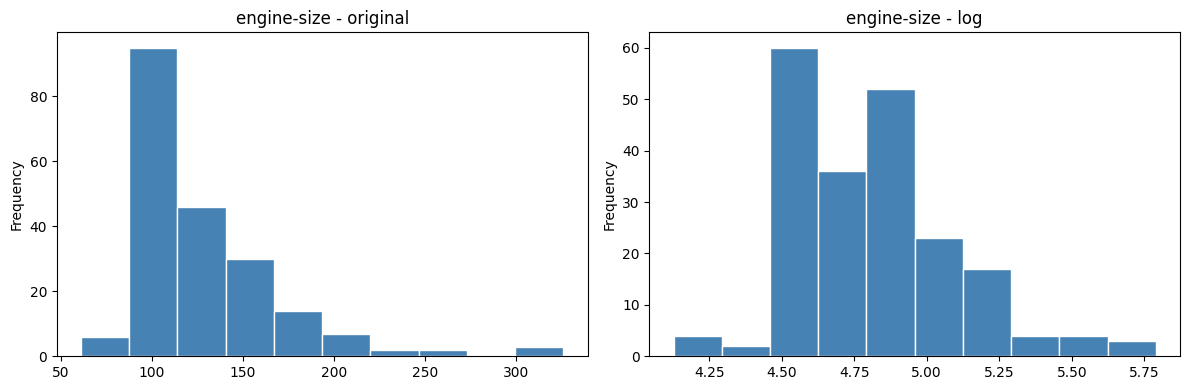

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['engine-size'].plot(kind='hist', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('engine-size - original')

#reduzir a distância entre valores muito grandes e pequenos
df['engine-size_log'] = (df['engine-size'] + 1).apply(np.log)

#usamos o .apply(np.log) para "esmagar" os valores grandes e aproximar os dados

df['engine-size_log'].plot(kind='hist', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('engine-size - log')i


plt.tight_layout()
plt.show()

In [16]:
cortes = [0, 100, 200, 500]
nomes = ['Pequeno', 'Médio', 'Grande']

df['engine-size-cat'] = pd.cut(df['engine-size'], bins=cortes, labels=nomes)

print("\n--- Distribuição das Categorias de Motor ---")
print(df['engine-size-cat'].value_counts())


--- Distribuição das Categorias de Motor ---
engine-size-cat
Médio      128
Pequeno     66
Grande      11
Name: count, dtype: int64


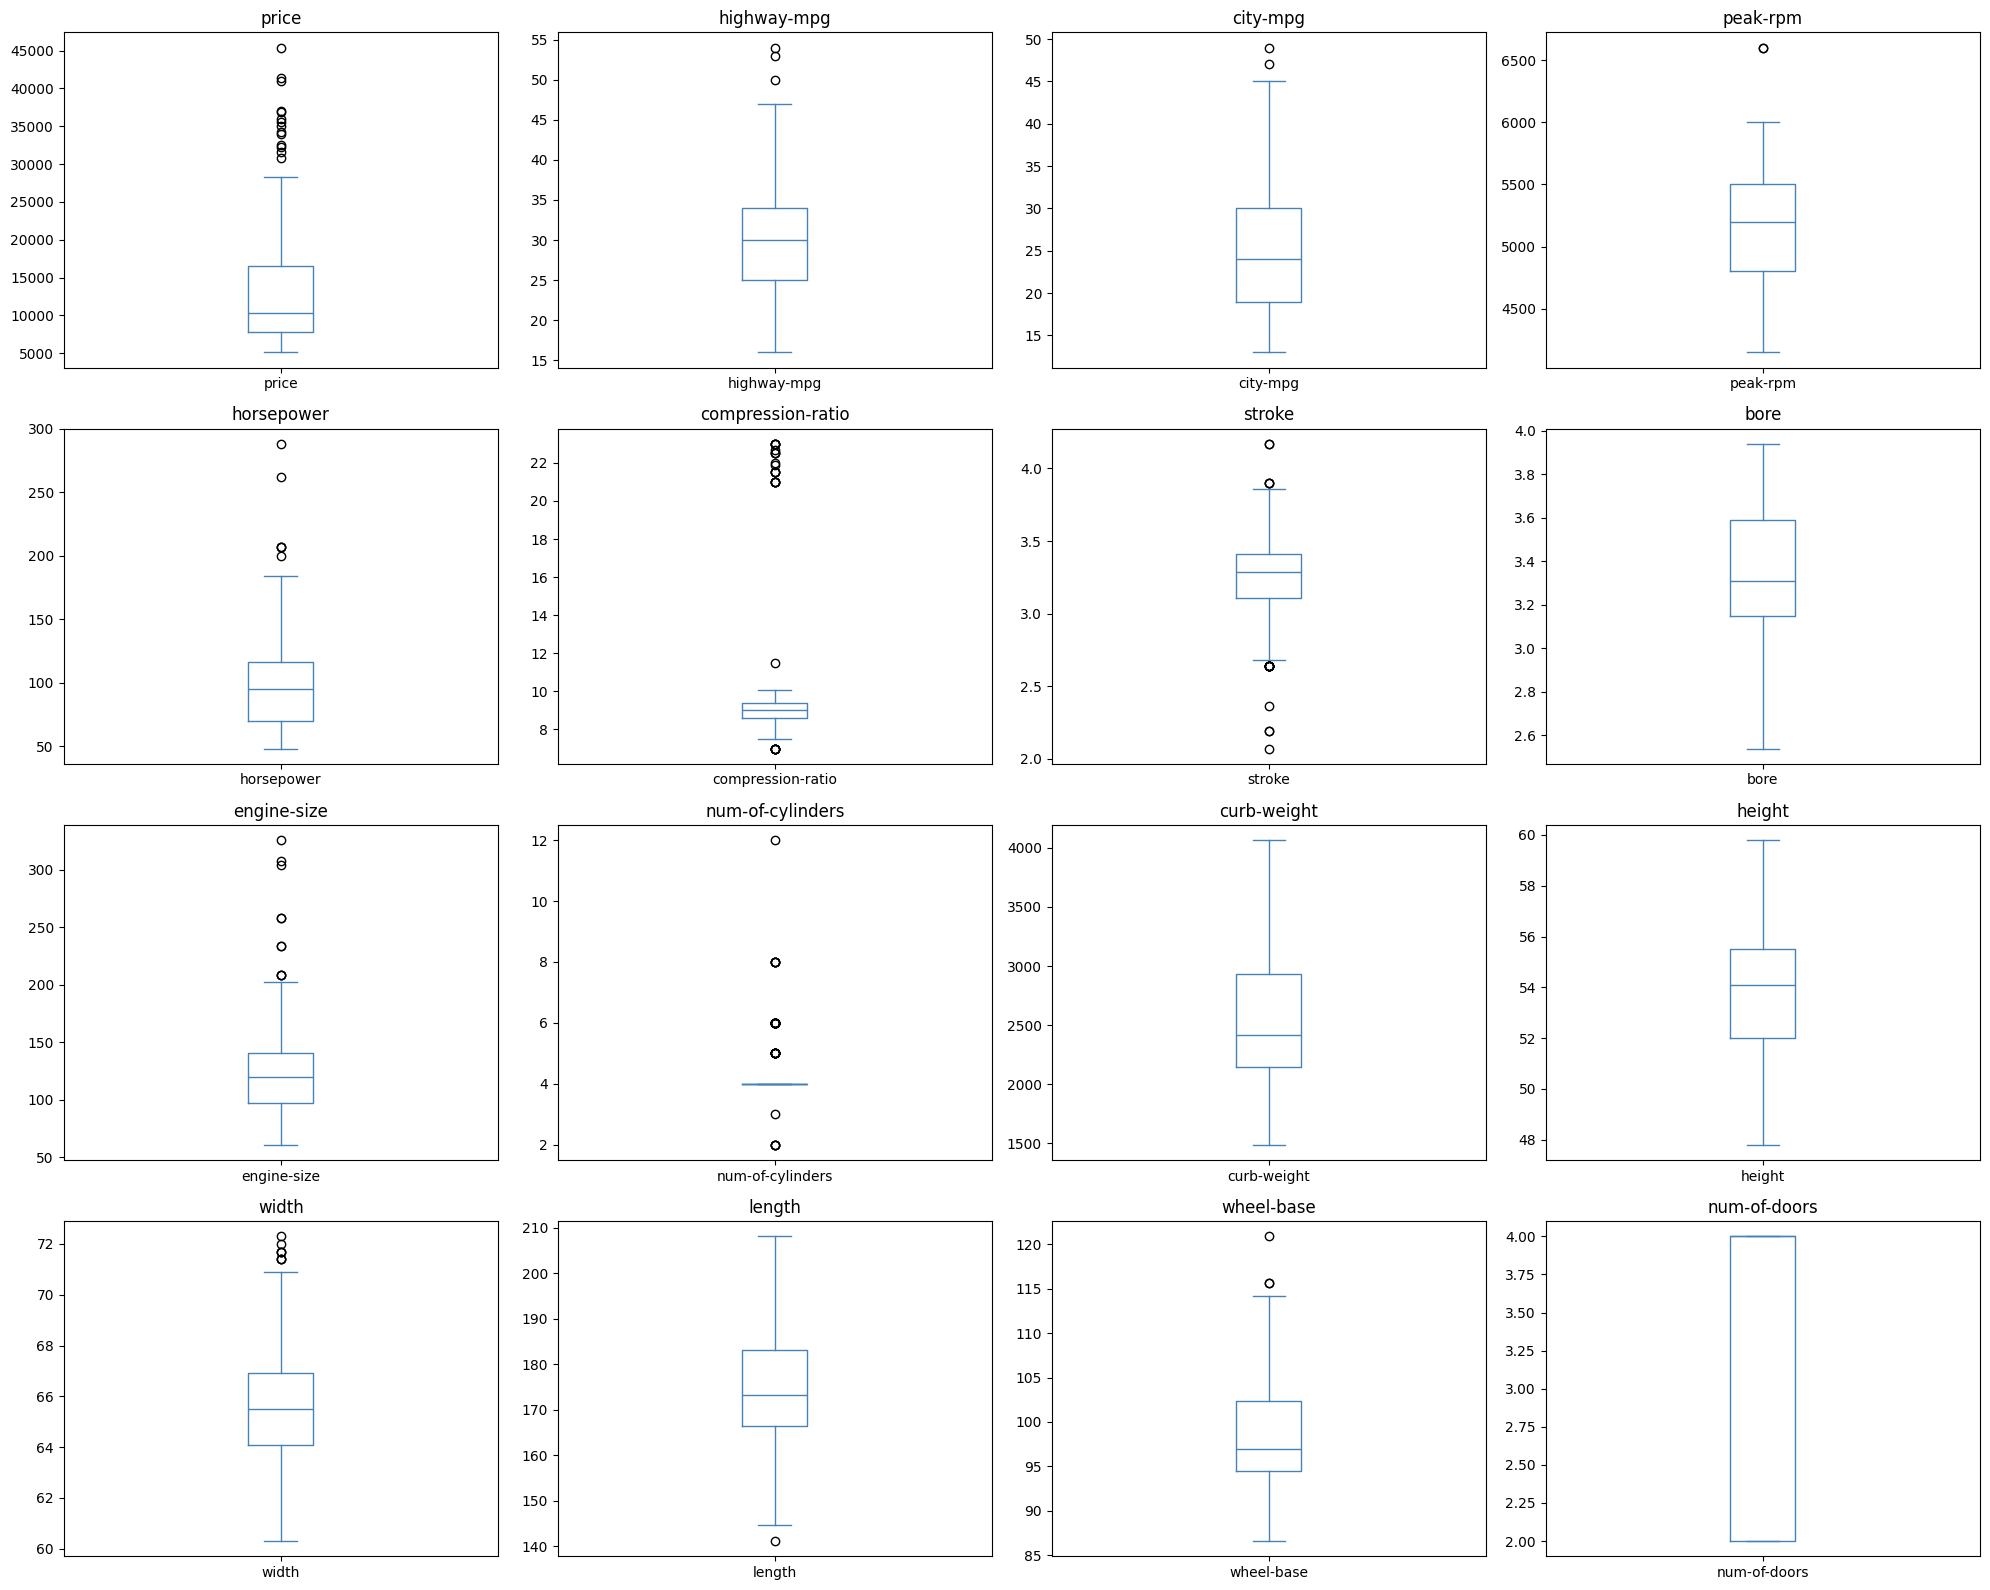

In [22]:
num_cols = df.select_dtypes(include='number').columns

#cria uma grelha de 4x4 (16 quadrados vazios) para os gráficos
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flatten(), num_cols):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col)

for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
list(zip(axes.flatten(), num_cols))

[(<Axes: title={'center': 'price'}>, 'price'),
 (<Axes: title={'center': 'highway-mpg'}>, 'highway-mpg'),
 (<Axes: title={'center': 'city-mpg'}>, 'city-mpg'),
 (<Axes: title={'center': 'peak-rpm'}>, 'peak-rpm'),
 (<Axes: title={'center': 'horsepower'}>, 'horsepower'),
 (<Axes: title={'center': 'compression-ratio'}>, 'compression-ratio'),
 (<Axes: title={'center': 'stroke'}>, 'stroke'),
 (<Axes: title={'center': 'bore'}>, 'bore'),
 (<Axes: title={'center': 'engine-size'}>, 'engine-size'),
 (<Axes: title={'center': 'num-of-cylinders'}>, 'num-of-cylinders'),
 (<Axes: title={'center': 'curb-weight'}>, 'curb-weight'),
 (<Axes: title={'center': 'height'}>, 'height'),
 (<Axes: title={'center': 'width'}>, 'width'),
 (<Axes: title={'center': 'length'}>, 'length'),
 (<Axes: title={'center': 'wheel-base'}>, 'wheel-base'),
 (<Axes: title={'center': 'num-of-doors'}>, 'num-of-doors')]

In [18]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_mask = (df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))

total_outliers = outliers_mask.sum()

print("\n--- Quantidade de Outliers por Coluna (Total Sum) ---")
print(total_outliers)


--- Quantidade de Outliers por Coluna (Total Sum) ---
price                14
highway-mpg           3
city-mpg              2
peak-rpm              2
horsepower            6
compression-ratio    28
stroke               20
bore                  0
engine-size          10
num-of-cylinders     46
curb-weight           0
height                0
width                 8
length                1
wheel-base            3
num-of-doors          0
normalized-losses     1
symboling             0
engine-size_log       5
dtype: int64


In [19]:
#suponhamos que a média do preço de carros é 13000
coluna = 'price'

media = df[coluna].mean()
dp = df[coluna].std()
n = len(df[coluna])

# dividimos o desvio padrão pela raiz quadrada do numero total de carros analisados
ea = dp / (n**0.5)

confi = 1.96

ic_lower = media - confi * ea
ic_upper = media + confi * ea

print(f"--- Intervalo de Confiança para {coluna} ---")
print(f"Média: {media:.2f}")
print(f"Intervalo de confiança (95%): [{ic_lower:.2f} a {ic_upper:.2f}]")

if 13000 >= ic_lower and 13000 <= ic_upper:
    print("Conclusão: A hipótese de que a média é 13.000 é sustentada pelos dados.")
else:
    print("Conclusão: A média real está significativamente fora da nossa hipótese inicial.")

--- Intervalo de Confiança para price ---
Média: 13207.13
Intervalo de confiança (95%): [12119.24 a 14295.02]
Conclusão: A hipótese de que a média é 13.000 é sustentada pelos dados.
